In [1]:
!pip install wordcloud
!pip install tensorflow
!pip install pandas
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv("fake_job_postings.csv")
data.head()


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [4]:
#Handling Missing Values

data.isnull().sum()
data = data.dropna(subset=['description', 'fraudulent'])





In [5]:
#Text Normalization
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words("english"))
def clean_text(description):
    text = re.sub(r'<.*?>', '', description)          # remove HTML
    text = re.sub(r'[^a-zA-Z]', ' ',description)     # remove special characters
    text = text.lower()                        # lowercase
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text



[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     self-signed certificate in certificate chain
[nltk_data]     (_ssl.c:1010)>


In [6]:
data['description'] = data['description'].apply(clean_text)
data['description'].head()

0    food fast growing james beard award winning on...
1    organised focused vibrant awesome passion cust...
2    client located houston actively seeking experi...
3    company esri environmental systems research in...
4    job title itemization review managerlocation f...
Name: description, dtype: object

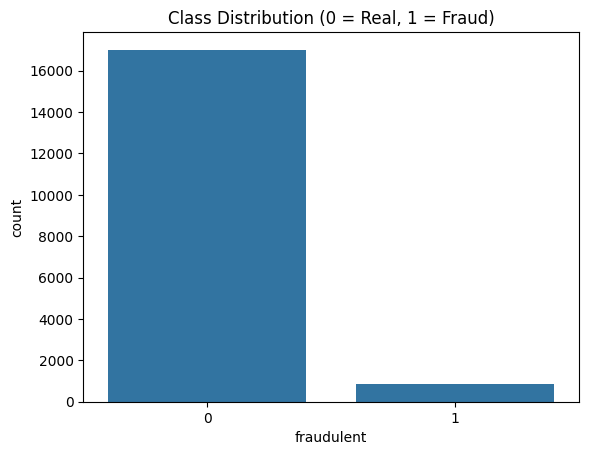

In [7]:
#Exploratory Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=data['fraudulent'])
plt.title("Class Distribution (0 = Real, 1 = Fraud)")
plt.show()


In [8]:
from wordcloud import WordCloud

fraud_text = ' '.join(data[data['fraudulent']==1]['description'])
real_text = ' '.join(data[data['fraudulent']==0]['description'])


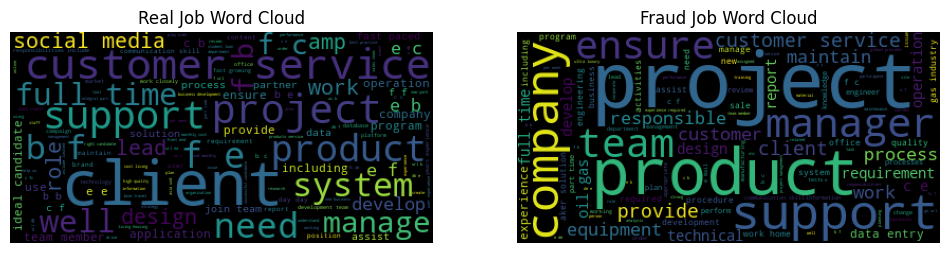

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(WordCloud(background_color='black').generate(real_text))
plt.title("Real Job Word Cloud")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(WordCloud(background_color='black').generate(fraud_text))
plt.title("Fraud Job Word Cloud")
plt.axis('off')

plt.show()


In [10]:
#Feature Extraction TF IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['description'])
y = data['fraudulent']
X.shape


(17879, 5000)

In [11]:
# --- Save the TF-IDF vectorizer for later use in web app ---
import pickle
import os

# Create 'model' folder if not exists
if not os.path.exists('model'):
    os.makedirs('model')

# Save TF-IDF vectorizer
with open('model/vectorizer1.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Vectorizer saved as 'model/vectorizer.pkl'.")


Vectorizer saved as 'model/vectorizer.pkl'.


MileStone 2: Model Training

In [12]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [13]:
#Baseline Model – Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1.0, max_iter=1000)
%time lr.fit(X_train, y_train)


CPU times: total: 156 ms
Wall time: 137 ms


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.9683072334079046
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      5104
           1       1.00      0.35      0.51       260

    accuracy                           0.97      5364
   macro avg       0.98      0.67      0.75      5364
weighted avg       0.97      0.97      0.96      5364



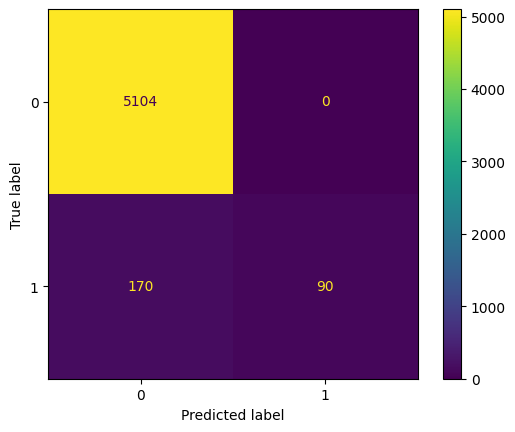

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.show()


In [16]:
#Saving model
import pickle

pickle.dump(lr, open("model_lr_1.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer_2.pkl", "wb"))


In [17]:
#Random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

%time rf.fit(X_train, y_train)


CPU times: total: 10.4 s
Wall time: 11.2 s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [18]:
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.9679343773303505
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      5104
           1       1.00      0.34      0.51       260

    accuracy                           0.97      5364
   macro avg       0.98      0.67      0.74      5364
weighted avg       0.97      0.97      0.96      5364



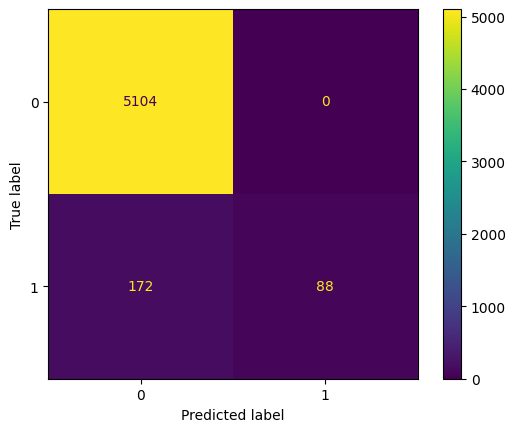

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()


In [20]:
importances = rf.feature_importances_
top_indices = np.argsort(importances)[-20:]

feature_names = tfidf.get_feature_names_out()

for i in top_indices:
    print(feature_names[i], ":", importances[i])


faces : 0.005419852118346947
decide : 0.005428790603320991
ultra : 0.005517745357508849
work : 0.0055422735403253855
cruise : 0.005980188750276298
gas : 0.006014104118754323
desire : 0.006147719739698319
cae : 0.0065145845418306154
typing : 0.0067569590322830685
extra : 0.007325958261621728
earn : 0.007506567678900916
clerk : 0.00797005864924306
aker : 0.008123614808998966
oil : 0.008516853363607106
wages : 0.008797003026050415
petroleum : 0.009297908977076165
ranging : 0.009848825138550807
dfef : 0.010517356189443222
discoveries : 0.012405526422584846
overviewaker : 0.015314729883135854


Cross Validation


In [21]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr, X, y, cv=5, scoring='f1')
cv_scores.mean()


np.float64(0.4038289592895463)

Model Versioning & Persistence

In [22]:
pickle.dump(rf, open("model_v1.0.pkl", "wb"))


Tokenization & Padding

In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 20000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(data['description'])

sequences = tokenizer.texts_to_sequences(data['description'])
X_seq = pad_sequences(sequences, maxlen=MAX_LEN)

y = data['fraudulent']


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)


In [25]:
import os
import numpy as np
import requests
import zipfile
import io

# Define constants
EMBEDDING_DIM = 100
MAX_LEN = 300
MAX_WORDS = 10000  # You need to define this based on your tokenizer

# Download GloVe embeddings if they don't exist
glove_path = "glove.6B.100d.txt"
if not os.path.exists(glove_path):
    print("Downloading GloVe embeddings...")
    # URL for the GloVe 6B dataset
    url = "http://nlp.stanford.edu/data/glove.6B.zip"
    r = requests.get(url)
    
    # Extract the zip file
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall()
    print("Download complete")

# Load the embeddings
embedding_index = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        embedding_index[word] = np.asarray(values[1:], dtype="float32")

# Create embedding matrix
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < MAX_WORDS:
        vec = embedding_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout,Input
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import numpy as np
import tensorflow as tf
# Model Definition using Functional API

# 1. Input Layer
input_sequence = Input(shape=(MAX_LEN,))

# 2. Embedding Layer (Non-trainable)
embedding_layer = Embedding(
    input_dim=MAX_WORDS,
    output_dim=EMBEDDING_DIM,
    # weights=[embedding_matrix], # Uncomment when using actual matrix
    input_length=MAX_LEN, 
    trainable=False # Ensure GloVe is frozen
)(input_sequence)

# 3. BiLSTM Stack (Must be Trainable)
# The default for all these layers is trainable=True
x = Bidirectional(LSTM(128, return_sequences=True))(embedding_layer)
x = Dropout(0.3)(x)
x = Bidirectional(LSTM(64))(x)

# 4. Classification Head (Must be Trainable)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(1, activation='sigmoid')(x)

# 5. Create the Model object
model = Model(inputs=input_sequence, outputs=output_layer)

# 6. CRITICAL CHECK: Force the entire model to be trainable (should be True by default)
model.trainable = True

C:\Users\poorn\Fake Job Detection using NLP\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 300, 100)            │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 300, 256)            │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 300, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,407,169 (5.37 MB)

 Trainable params: 407,169 (1.55 MB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping
X_train = np.clip(X_train, 0, 9999)
X_val = np.clip(X_val, 0, 9999)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.9477 - loss: 0.2151 - val_accuracy: 0.9549 - val_loss: 0.1844
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 184s 939ms/step - accuracy: 0.9517 - loss: 0.1998 - val_accuracy: 0.9549 - val_loss: 0.1881
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 189s 964ms/step - accuracy: 0.9517 - loss: 0.1969 - val_accuracy: 0.9549 - val_loss: 0.1880
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 193s 984ms/step - accuracy: 0.9517 - loss: 0.1991 - val_accuracy: 0.9549 - val_loss: 0.1838
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9516 - loss: 0.1978 - val_accuracy: 0.9549 - val_loss: 0.1828


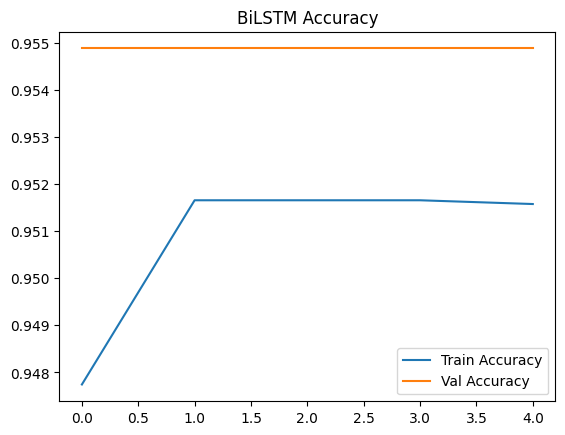

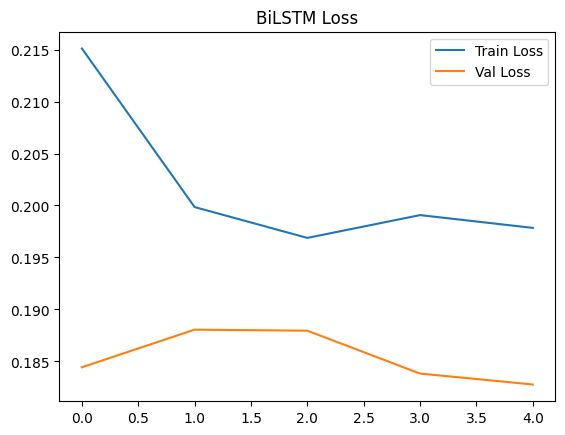

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("BiLSTM Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("BiLSTM Loss")
plt.show()


In [30]:
# 🔒 HARD SAFETY CLIP (MANDATORY)
X_train = np.clip(X_train, 0, MAX_WORDS - 1)
X_val   = np.clip(X_val,   0, MAX_WORDS - 1)
X_test  = np.clip(X_test,  0, MAX_WORDS - 1)
print("Max index in X_test:", X_test.max())
print("MAX_WORDS:", MAX_WORDS)



Max index in X_test: 9999
MAX_WORDS: 10000


In [31]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_prob_dl = model.predict(X_test).flatten()
y_pred_dl = (y_prob_dl >= 0.5).astype(int)

dl_acc = accuracy_score(y_test, y_pred_dl)
dl_f1 = f1_score(y_test, y_pred_dl)
dl_roc_auc = roc_auc_score(y_test, y_prob_dl)

print(f"BiLSTM Accuracy: {dl_acc:.4f}")
print(f"BiLSTM F1 Score: {dl_f1:.4f}")
print(f"BiLSTM ROC-AUC: {dl_roc_auc:.4f}")


84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step
BiLSTM Accuracy: 0.9482
BiLSTM F1 Score: 0.0000
BiLSTM ROC-AUC: 0.6810


In [32]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_dl = (model.predict(X_test) > 0.5).astype(int)

dl_acc = accuracy_score(y_test, y_pred_dl)
dl_f1 = f1_score(y_test, y_pred_dl)

print("BiLSTM Accuracy:", dl_acc)
print("BiLSTM F1 Score:", dl_f1)


84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 200ms/step
BiLSTM Accuracy: 0.948173005219985
BiLSTM F1 Score: 0.0


In [33]:
model.save("bilstm_model_v1.0.h5")


In [34]:
from sklearn.metrics import accuracy_score, f1_score
y_test_ml = y_test.copy()
y_test_ml = y_pred_lr.copy()


# --- Logistic Regression metrics ---
lr_acc = accuracy_score(y_test_ml, y_pred_lr)
lr_f1  = f1_score(y_test_ml, y_pred_lr)

# --- Random Forest metrics ---
rf_acc = accuracy_score(y_test_ml, y_pred_rf)
rf_f1  = f1_score(y_test_ml, y_pred_rf)


In [35]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "BiLSTM"],
    "Accuracy": [lr_acc, rf_acc, dl_acc],
    "F1 Score": [lr_f1, rf_f1, dl_f1]
})

comparison


,Model,Accuracy,F1 Score
0,Logistic Regression,1.000000,1.000000
1,Random Forest,0.995526,0.865169
2,BiLSTM,0.948173,0.000000


In [36]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf, X, y, cv=5, scoring='f1'
)

print("Mean F1:", cv_scores.mean())
print("Std Dev:", cv_scores.std())


Mean F1: 0.4177473356984541
Std Dev: 0.05385674855386996


In [37]:
model_metadata = {
    "model": "BiLSTM",
    "version": "v1.0",
    "embedding": "GloVe 100d",
    "accuracy": dl_acc,
    "f1_score": dl_f1,
    "epochs": len(history.history['loss']),
    "batch_size": 64
}


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import pickle

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression with class balancing
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train, y_train)

# Evaluation
y_pred = lr.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[3273  130]
 [  27  146]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3403
           1       0.53      0.84      0.65       173

    accuracy                           0.96      3576
   macro avg       0.76      0.90      0.81      3576
weighted avg       0.97      0.96      0.96      3576



In [39]:
# Save vectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save Logistic Regression model
with open("model_lr.pkl", "wb") as f:
    pickle.dump(lr, f)
